<img src="https://dauphine.psl.eu/fileadmin/_processed_/9/2/csm_damier_logo_Dauphine_f7b37a1ff2.jpg" width="200" style="vertical-align:middle" /> <h1>Master 222: Introduction to Python - Session 5</h1>





[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zaltarba/PSL_python_for_finance/blob/main/python_session_5.ipynb)

# Introduction to yfinance

### What is yfinance?

`yfinance` stands for Yahoo Finance, and the `yfinance` library in Python allows you to access financial data from Yahoo! Finance. This can include stock prices, historical data, financial statements, and much more.

### Why use `yfinance`?

If you're interested in financial analysis, algorithmic trading, or just want to understand how the stock market behaves over time, `yfinance` is a great tool to start with. With just a few lines of Python code, you can retrieve vast amounts of financial data.

### Getting Started

Start by importing the library:
```
import yfinance as yf
```
Fetching Data:

You can fetch data for a specific stock or index. Here's how to get the historical data for Apple Inc. (AAPL) for the past month:
```
data = yf.download("AAPL", period="1mo")
print(data)
```

- Fetch the data for AAPL
- Using matplotlib.pyplot, plot the closing prices



In [5]:
import yfinance as yf
import matplotlib.pyplot as plt


/tmp/ipykernel_1364/1839859804.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download('AAPL', period='1y')
[*********************100%***********************]  1 of 1 completed


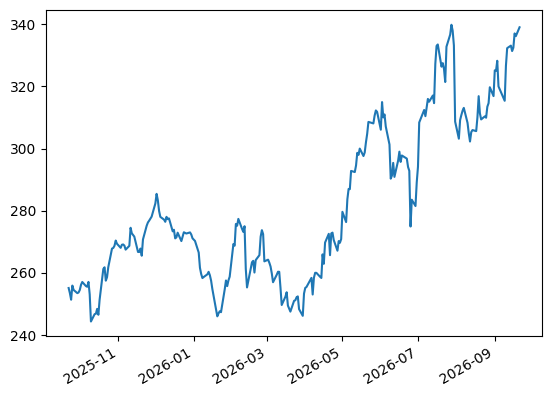

In [15]:
data=yf.download('AAPL', period='1y')
plt.plot(data['Close'])
plt.gcf().autofmt_xdate()
plt.show()

**Exercise: Analyzing Historical Stock Prices**
> Context:
You are a financial analyst at an investment firm. You have been given a dataset containing historical stock prices of several companies over the past decade. Your task is to clean, analyze, and visualize the data to help the firm make informed investment decisions.

> Dataset:
The dataset contains the following columns: 'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume'.


**Data Loading and Inspection**:

- Fetch the historical stock price data for 'AAPL'.
- Display the first 10 rows of the dataset.
- Check for any missing values in the dataset.

**Data Cleaning**:

- Handle any missing values: You can either fill them using methods such as forward fill, backward fill, or interpolation, or you can choose to drop rows with missing values.
- Convert the 'Date' column to a datetime format if it isn't already..

**Data Transformation**:

- Make the 'Date' column the index of the DataFrame to facilitate time series analysis.
- Compute a new column 'Price_Average', which is the arithmetic mean of the 'High' and 'Low' prices for each trading day.

**Data Analysis**:

- Determine the specific date when the trading volume for Apple Inc. was at its peak.
- Compute the monthly average of the 'Close' price to understand monthly performance trends.

**Data Aggregation**:

- Calculate the total trading volume and average closing price for each company over the period.

**File I/O**:

- Save the cleaned and transformed dataset to a new CSV file.
- Save the plots as image files.

**Bonus**:

- Use a simple linear regression model to attempt predictions of future stock prices based on historical data. This will provide a rudimentary forecast which can be enhanced with more complex models.
- Implement a basic moving average trading strategy. For instance, consider using a 50-day and a 200-day moving average. Generate buy signals when the 50-day moving average crosses above the 200-day moving average, and sell signals when it crosses below. Backtest this strategy to gauge its historical performance.

In [38]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
tickers=['AAPL','MSFT','TSLA','NVO','MC.PA','OR.PA','NVDA','BNP.PA','TTE.PA']
data=yf.download(tickers,period='10y')
data.head(10)

/tmp/ipykernel_1364/4008341938.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(tickers,period='10y')
[*********************100%***********************]  9 of 9 completed


Price           Close                                                         \
Ticker           AAPL     BNP.PA       MC.PA       MSFT      NVDA        NVO   
Date                                                                           
2016-09-22  26.211943  27.494658  129.032791  51.342270  1.595125  18.039003   
2016-09-23  25.775164  27.294117  128.656250  50.995953  1.593408  17.765862   
2016-09-26  25.814037  26.401842  126.982674  50.525345  1.578443  17.587729   
2016-09-27  25.862059  26.265247  127.066330  51.457699  1.632416  17.358133   
2016-09-28  26.058725  26.515196  127.526573  51.528725  1.638304  17.314592   
2016-09-29  25.653957  26.393126  126.104004  50.969322  1.653514  16.546637   
2016-09-30  25.852907  26.605293  127.024475  51.146927  1.680990  16.463511   
2016-10-03  25.731709  26.515196  127.191856  50.987068  1.679273  16.277456   
2016-10-04  25.841478  26.756428  131.041092  50.827255  1.675593  16.083488   
2016-10-05  25.852907  27.669039  130.748230  51.182442  1.673876  16.435799   

Price                                              High  ...       Open  \
Ticker           OR.PA       TSLA     TTE.PA       AAPL  ...     TTE.PA   
Date                                                     ...              
2016-09-22  144.866989  13.762000  23.901091  26.285122  ...  23.265467   
2016-09-23  144.269424  13.830000  23.612423  26.250830  ...  23.798391   
2016-09-26  142.263306  13.932667  23.165548  25.930668  ...  23.373722   
2016-09-27  143.031586  13.720667  22.968374  25.882641  ...  23.362730   
2016-09-28  143.799911  13.751333  23.081041  26.216519  ...  23.097942   
2016-09-29  143.116974  13.380000  24.038769  26.024429  ...  24.210595   
2016-09-30  143.501160  13.602000  23.757080  25.926087  ...  23.678209   
2016-10-03  143.629166  14.246667  23.844404  25.852913  ...  23.802151   
2016-10-04  145.421875  14.094000  24.286648  26.141056  ...  23.886659   
2016-10-05  141.879135  13.897333  24.264111  25.992406  ...  23.990878   

Price            Volume                                                 \
Ticker             AAPL     BNP.PA      MC.PA        MSFT         NVDA   
Date                                                                     
2016-09-22  124296000.0  5030250.0   845731.0  19822200.0  308732000.0   
2016-09-23  209924800.0  3697080.0   534423.0  19955300.0  276132000.0   
2016-09-26  119477600.0  3919481.0   524416.0  21688700.0  230040000.0   
2016-09-27   98429600.0  4208318.0   577866.0  28065100.0  402752000.0   
2016-09-28  118564400.0  3447639.0   435720.0  20536400.0  319788000.0   
2016-09-29  143548000.0  2463934.0   479949.0  25463500.0  336684000.0   
2016-09-30  145516400.0  6379925.0   743922.0  29910800.0  429932000.0   
2016-10-03   86807200.0  1773168.0   324385.0  19189500.0  242596000.0   
2016-10-04  118947200.0  2739790.0  1109267.0  20085900.0  281624000.0   
2016-10-05   85812400.0  5192510.0   614540.0  16726400.0  305440000.0   

Price                                                    
Ticker             NVO     OR.PA        TSLA     TTE.PA  
Date                                                     
2016-09-22   4693000.0  665852.0  35743500.0  7651893.0  
2016-09-23   7747800.0  353632.0  43578000.0  5818834.0  
2016-09-26   3881400.0  456439.0  35916000.0  6268784.0  
2016-09-27   6298400.0  433051.0  50598000.0  6137801.0  
2016-09-28   5844600.0  382823.0  31326000.0  4402576.0  
2016-09-29   9584200.0  354474.0  40905000.0  7934813.0  
2016-09-30  11301000.0  580712.0  38794500.0  7665326.0  
2016-10-03   7161800.0  343323.0  89998500.0  4144437.0  
2016-10-04  10758800.0  549128.0  53122500.0  5844520.0  
2016-10-05  10034000.0  487257.0  28162500.0  5933056.0  

[10 rows x 45 columns]

In [62]:
data['Close'].isna().sum()

,0
Ticker,
AAPL,71
BNP.PA,25
MC.PA,25
MSFT,71
NVDA,71
NVO,71
OR.PA,25
TSLA,71
TTE.PA,25


In [65]:
data=data.ffill()
data.isna().any()

Price   Ticker
Close   AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
High    AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Low     AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Open    AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Volume  AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
dtype: bool

In [66]:
print(data.index.dtype)

datetime64[ns]


In [67]:
data['Price Average'] = data[['High','Low']].mean(axis=1)
data.head(10)

Price           Close                                                         \
Ticker           AAPL     BNP.PA       MC.PA       MSFT      NVDA        NVO   
Date                                                                           
2016-09-22  26.211943  27.494658  129.032791  51.342270  1.595125  18.039003   
2016-09-23  25.775164  27.294117  128.656250  50.995953  1.593408  17.765862   
2016-09-26  25.814037  26.401842  126.982674  50.525345  1.578443  17.587729   
2016-09-27  25.862059  26.265247  127.066330  51.457699  1.632416  17.358133   
2016-09-28  26.058725  26.515196  127.526573  51.528725  1.638304  17.314592   
2016-09-29  25.653957  26.393126  126.104004  50.969322  1.653514  16.546637   
2016-09-30  25.852907  26.605293  127.024475  51.146927  1.680990  16.463511   
2016-10-03  25.731709  26.515196  127.191856  50.987068  1.679273  16.277456   
2016-10-04  25.841478  26.756428  131.041092  50.827255  1.675593  16.083488   
2016-10-05  25.852907  27.669039  130.748230  51.182442  1.673876  16.435799   

Price                                              High  ...       Volume  \
Ticker           OR.PA       TSLA     TTE.PA       AAPL  ...         AAPL   
Date                                                     ...                
2016-09-22  144.866989  13.762000  23.901091  26.285122  ...  124296000.0   
2016-09-23  144.269424  13.830000  23.612423  26.250830  ...  209924800.0   
2016-09-26  142.263306  13.932667  23.165548  25.930668  ...  119477600.0   
2016-09-27  143.031586  13.720667  22.968374  25.882641  ...   98429600.0   
2016-09-28  143.799911  13.751333  23.081041  26.216519  ...  118564400.0   
2016-09-29  143.116974  13.380000  24.038769  26.024429  ...  143548000.0   
2016-09-30  143.501160  13.602000  23.757080  25.926087  ...  145516400.0   
2016-10-03  143.629166  14.246667  23.844404  25.852913  ...   86807200.0   
2016-10-04  145.421875  14.094000  24.286648  26.141056  ...  118947200.0   
2016-10-05  141.879135  13.897333  24.264111  25.992406  ...   85812400.0   

Price                                                                  \
Ticker         BNP.PA      MC.PA        MSFT         NVDA         NVO   
Date                                                                    
2016-09-22  5030250.0   845731.0  19822200.0  308732000.0   4693000.0   
2016-09-23  3697080.0   534423.0  19955300.0  276132000.0   7747800.0   
2016-09-26  3919481.0   524416.0  21688700.0  230040000.0   3881400.0   
2016-09-27  4208318.0   577866.0  28065100.0  402752000.0   6298400.0   
2016-09-28  3447639.0   435720.0  20536400.0  319788000.0   5844600.0   
2016-09-29  2463934.0   479949.0  25463500.0  336684000.0   9584200.0   
2016-09-30  6379925.0   743922.0  29910800.0  429932000.0  11301000.0   
2016-10-03  1773168.0   324385.0  19189500.0  242596000.0   7161800.0   
2016-10-04  2739790.0  1109267.0  20085900.0  281624000.0  10758800.0   
2016-10-05  5192510.0   614540.0  16726400.0  305440000.0  10034000.0   

Price                                       Price Average  
Ticker         OR.PA        TSLA     TTE.PA                
Date                                                       
2016-09-22  665852.0  35743500.0  7651893.0     48.221339  
2016-09-23  353632.0  43578000.0  5818834.0     48.225932  
2016-09-26  456439.0  35916000.0  6268784.0     47.707775  
2016-09-27  433051.0  50598000.0  6137801.0     47.679267  
2016-09-28  382823.0  31326000.0  4402576.0     47.992057  
2016-09-29  354474.0  40905000.0  7934813.0     47.901918  
2016-09-30  580712.0  38794500.0  7665326.0     47.330613  
2016-10-03  343323.0  89998500.0  4144437.0     47.707901  
2016-10-04  549128.0  53122500.0  5844520.0     48.143117  
2016-10-05  487257.0  28162500.0  5933056.0     48.154294  

[10 rows x 46 columns]

In [68]:
max_volume_date=data['Volume'].idxmax()
max_volume_date

,0
Ticker,
AAPL,2017-02-01
BNP.PA,2020-03-12
MC.PA,2020-03-12
MSFT,2026-06-26
NVDA,2017-06-09
NVO,2025-07-29
OR.PA,2020-03-12
TSLA,2020-02-04
TTE.PA,2020-03-09


In [81]:
monthly_data = pd.DataFrame({
    'Close': data['Close'].resample('ME').mean(),
    'Volume': data['Volume'].resample('ME').sum()
})
monthly_data.head(10)

ValueError: Cannot set a DataFrame with multiple columns to the single column Volume

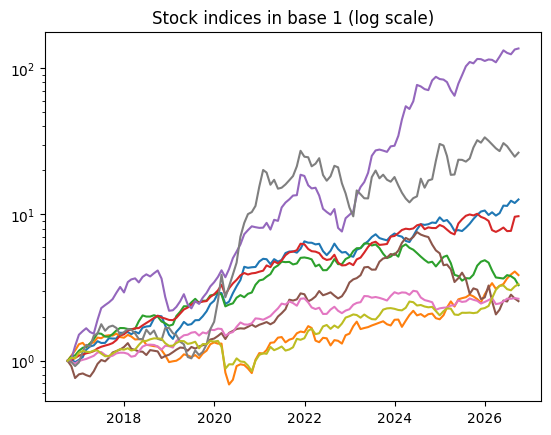

In [80]:
monthly_prices_index=monthly_data/monthly_data.iloc[0]
plt.plot(monthly_prices_index)
plt.title('Stock indices in base 1 (log scale)')
plt.yscale('log')
plt.show()

In [70]:
total_trading_volume=data['Volume'].sum()
total_trading_volume

,0
Ticker,
AAPL,2.407829e+11
BNP.PA,9.289141e+09
MC.PA,1.335934e+09
MSFT,7.133564e+10
NVDA,1.142328e+12
NVO,1.391279e+10
OR.PA,1.143667e+09
TSLA,2.950000e+11
TTE.PA,1.452521e+10


**Exercice TO DO: Momentum Strategy on 50 Stocks**

## Objective
Explore the performance of a simple momentum strategy on a subset of 50 stocks.

## Procedure

### 1. Stock Selection
- Use `pandas` to fetch the list of all tickers from [this link](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies)
    - Use pd.read_html
- Randomly select 50 stocks from this list.

### 2. Data Collection
- For each stock, download the daily adjusted closing prices for the last 365 days.
- Store this data in a pandas DataFrame with dates as the index.

### 3. Momentum Calculation
- Define momentum as the percentage change in the stock price over the previous n days (e.g., n=21 for a month).
- Using pandas, compute the momentum for each stock for each day.
- Rank the stocks based on their momentum every day.

### 4. Strategy

1. At the beginning of each month, buy the top 10 stocks based on momentum from the previous month.
2. At the end of the month, sell all the stocks.
3. Repeat this process for each month in your dataset.

### 5. Performance Analysis

- Calculate the monthly and annualized return of this strategy.
- Compare the strategy's performance against a benchmark (e.g., S&P 500).
- Plot the cumulative returns of your strategy and the benchmark.

### 6. Risk Analysis
- Using numpy, compute the standard deviation of the monthly returns to get a measure of the strategy's risk.
- Calculate the Sharpe Ratio.

## Hints

- To get the tickers list:
```python
import requests

# URL of the Wikipedia page
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

# Set headers to mimic a browser
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Send the HTTP request with custom headers
response = requests.get(url, headers=headers)

# Use pandas to read the HTML from the response content
tables = pd.read_html(response.text)
```

In [ ]:
## Insert your code here